In [33]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.gridspec as gridspec
import numpy as np
import glob

## DATA LOADING & CLEANING

In [53]:
def load_logs(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.json_normalize(data)

baseline_df = load_logs('data/baseline_architecture_log.json')
spear_df = load_logs('data/spear_mistral-small3.2-llama3.2.json')
df = pd.concat([baseline_df, spear_df], ignore_index=True)


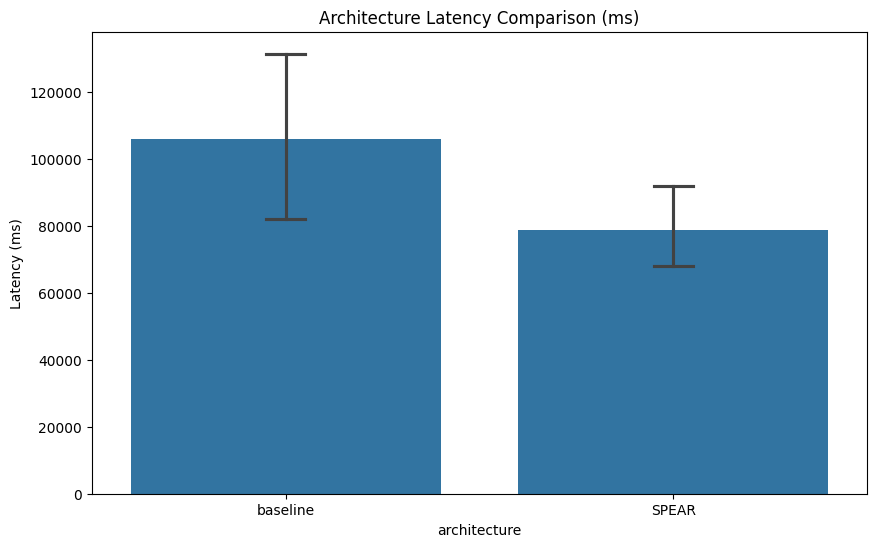

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='latency_ms', data=df, capsize=.1)
plt.title('Architecture Latency Comparison (ms)')
plt.ylabel('Latency (ms)')
plt.show()


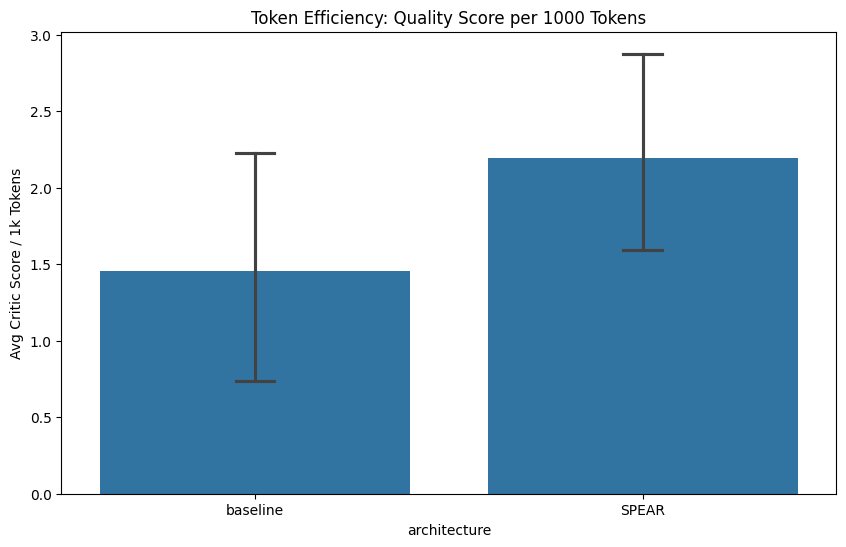

In [36]:
critic_cols = [
    'async_critic_scores.rule_accuracy', 
    'async_critic_scores.narrative_coherence', 
    'async_critic_scores.npc_voice_consistency'
]
df['avg_critic_score'] = df[critic_cols].mean(axis=1)
df['total_critic_score'] = df[critic_cols].sum(axis=1)
df['score_per_1k_tokens'] = (df['avg_critic_score'] / df['total_tokens']) * 1000

plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='score_per_1k_tokens', data=df, capsize=.1)
plt.title('Token Efficiency: Quality Score per 1000 Tokens')
plt.ylabel('Avg Critic Score / 1k Tokens')
plt.show()

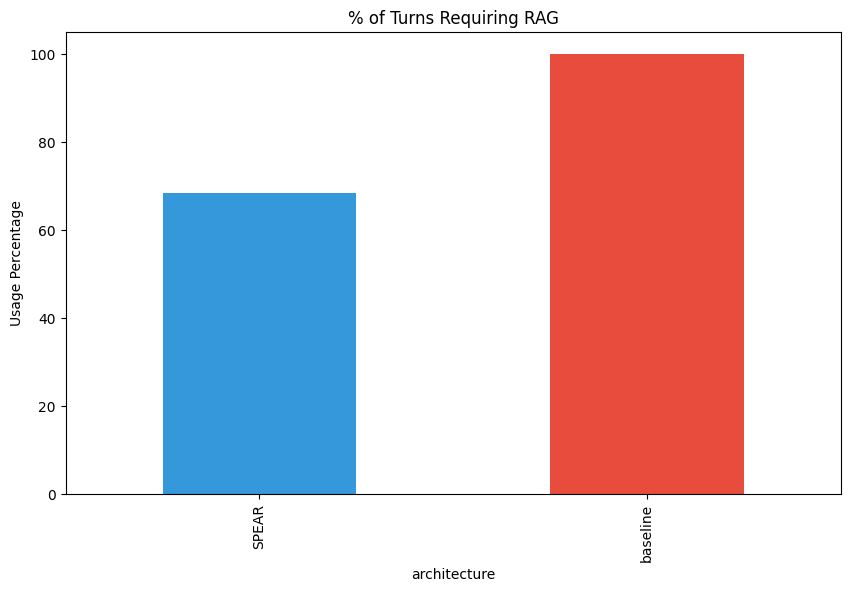

In [37]:
plt.figure(figsize=(10, 6))
rag_usage = df.groupby('architecture')['retrieval_types.rag_vector'].mean() * 100
rag_usage.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('% of Turns Requiring RAG')
plt.ylabel('Usage Percentage')
plt.show()

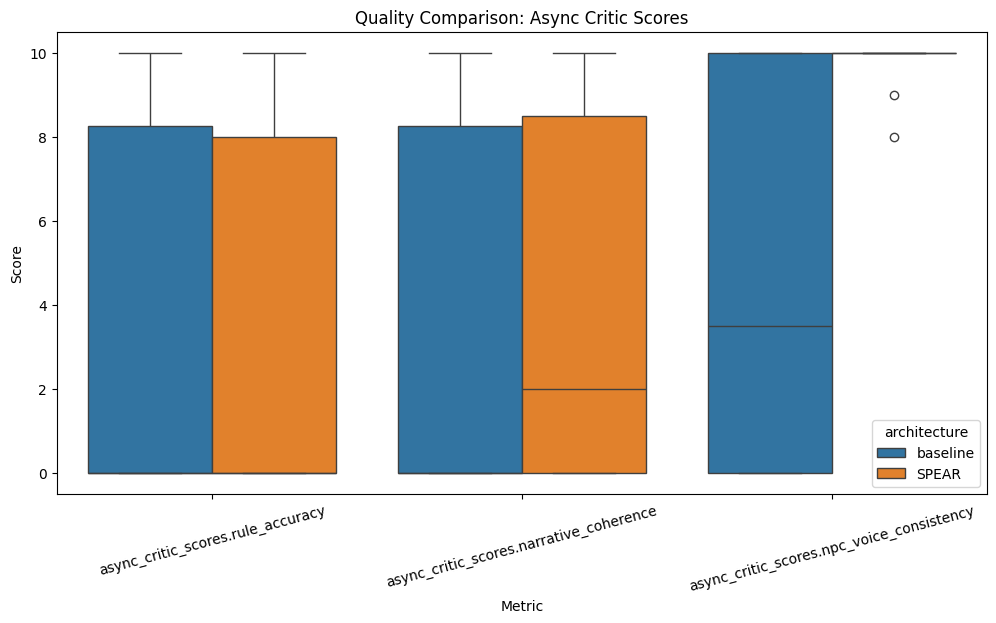

In [38]:
critic_cols = [
    'async_critic_scores.rule_accuracy', 
    'async_critic_scores.narrative_coherence', 
    'async_critic_scores.npc_voice_consistency'
]

# Standardize scores (Handling 0s or NaNs)
melted_df = df.melt(id_vars=['architecture'], value_vars=critic_cols, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Metric', y='Score', hue='architecture', data=melted_df)
plt.title('Quality Comparison: Async Critic Scores')
plt.xticks(rotation=15)
plt.show()

In [39]:
hallucination_rate = spear_df['routing_hallucination'].mean() * 100
print(f"SPEAR Routing Hallucination Rate: {hallucination_rate:.2f}%")

SPEAR Routing Hallucination Rate: 0.00%


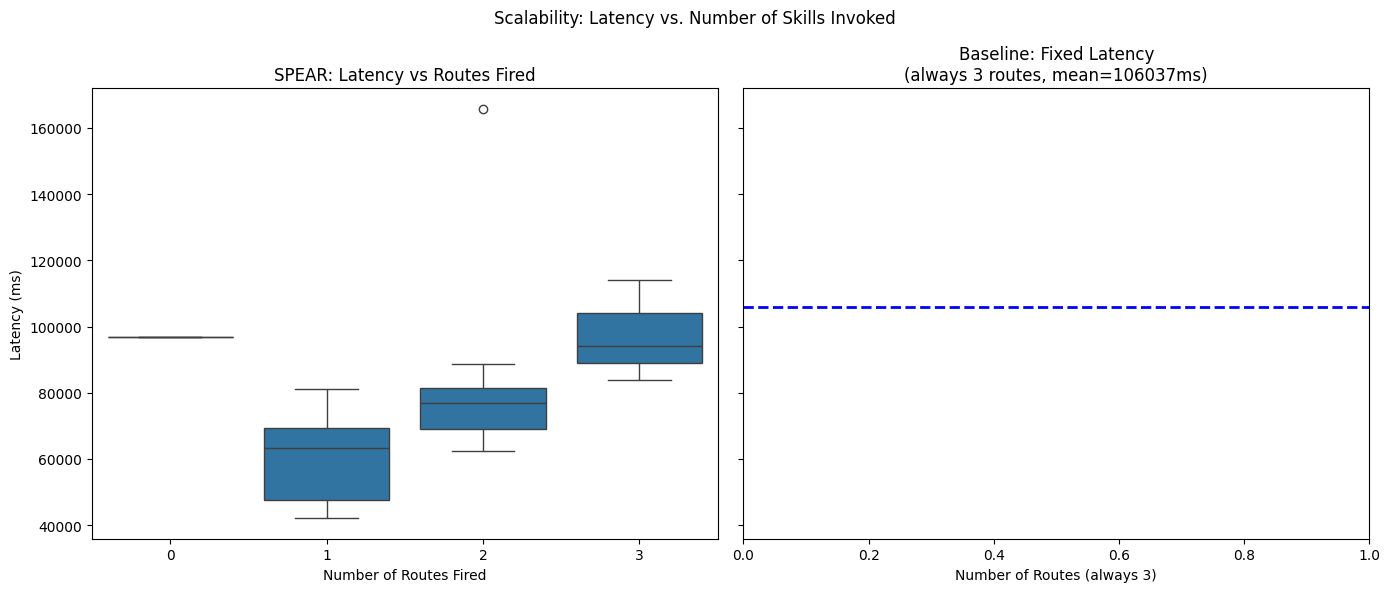

In [40]:
# Compute BEFORE filtering
df['num_routes'] = df['routes_fired.rules_logic'].astype(int) + \
                   df['routes_fired.npc_lore'].astype(int) + \
                   df['routes_fired.world_exploration'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Filter AFTER num_routes exists
spear_data = df[df['architecture'] == 'SPEAR']

sns.boxplot(x='num_routes', y='latency_ms', data=spear_data, ax=axes[0])
axes[0].set_title('SPEAR: Latency vs Routes Fired')
axes[0].set_xlabel('Number of Routes Fired')
axes[0].set_ylabel('Latency (ms)')

baseline_mean = df[df['architecture'] == 'baseline']['latency_ms'].mean()
axes[1].axhline(y=baseline_mean, color='blue', linestyle='--', linewidth=2)
axes[1].set_title(f'Baseline: Fixed Latency\n(always 3 routes, mean={baseline_mean:.0f}ms)')
axes[1].set_xlabel('Number of Routes (always 3)')

plt.suptitle('Scalability: Latency vs. Number of Skills Invoked')
plt.tight_layout()
plt.show()

In [41]:
# 1. Standardize the columns
df['num_routes'] = df['routes_fired.rules_logic'].astype(int) + \
                   df['routes_fired.npc_lore'].astype(int) + \
                   df['routes_fired.world_exploration'].astype(int)

# 2. Corrected Sparsity Calculation
spear_mask = df['architecture'] == 'SPEAR'
spear_data = df[spear_mask]

if len(spear_data) > 0:
    total_possible_slots = len(spear_data) * 3
    total_actual_slots = spear_data['num_routes'].sum()
    sparsity_val = (1 - (total_actual_slots / total_possible_slots)) * 100

    # THE FIX: Added the 'f' prefix to the string below
    print(f"SPEAR Skill Sparsity: {sparsity_val:.2f}%")
    print(f"Interpretation: SPEAR successfully avoided loading unneeded skills in {sparsity_val:.2f}% of potential cases.")
else:
    print("Error: No SPEAR logs found in the dataframe.")

SPEAR Skill Sparsity: 43.86%
Interpretation: SPEAR successfully avoided loading unneeded skills in 43.86% of potential cases.


/tmp/ipykernel_334828/2762354624.py:11: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(subset['num_routes'], subset['avg_critic_score'], 1)
/tmp/ipykernel_334828/2762354624.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_arch, labels=archs, patch_artist=True,
/tmp/ipykernel_334828/2762354624.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(hallu_data, labels=hallu_order, patch_artist=True,


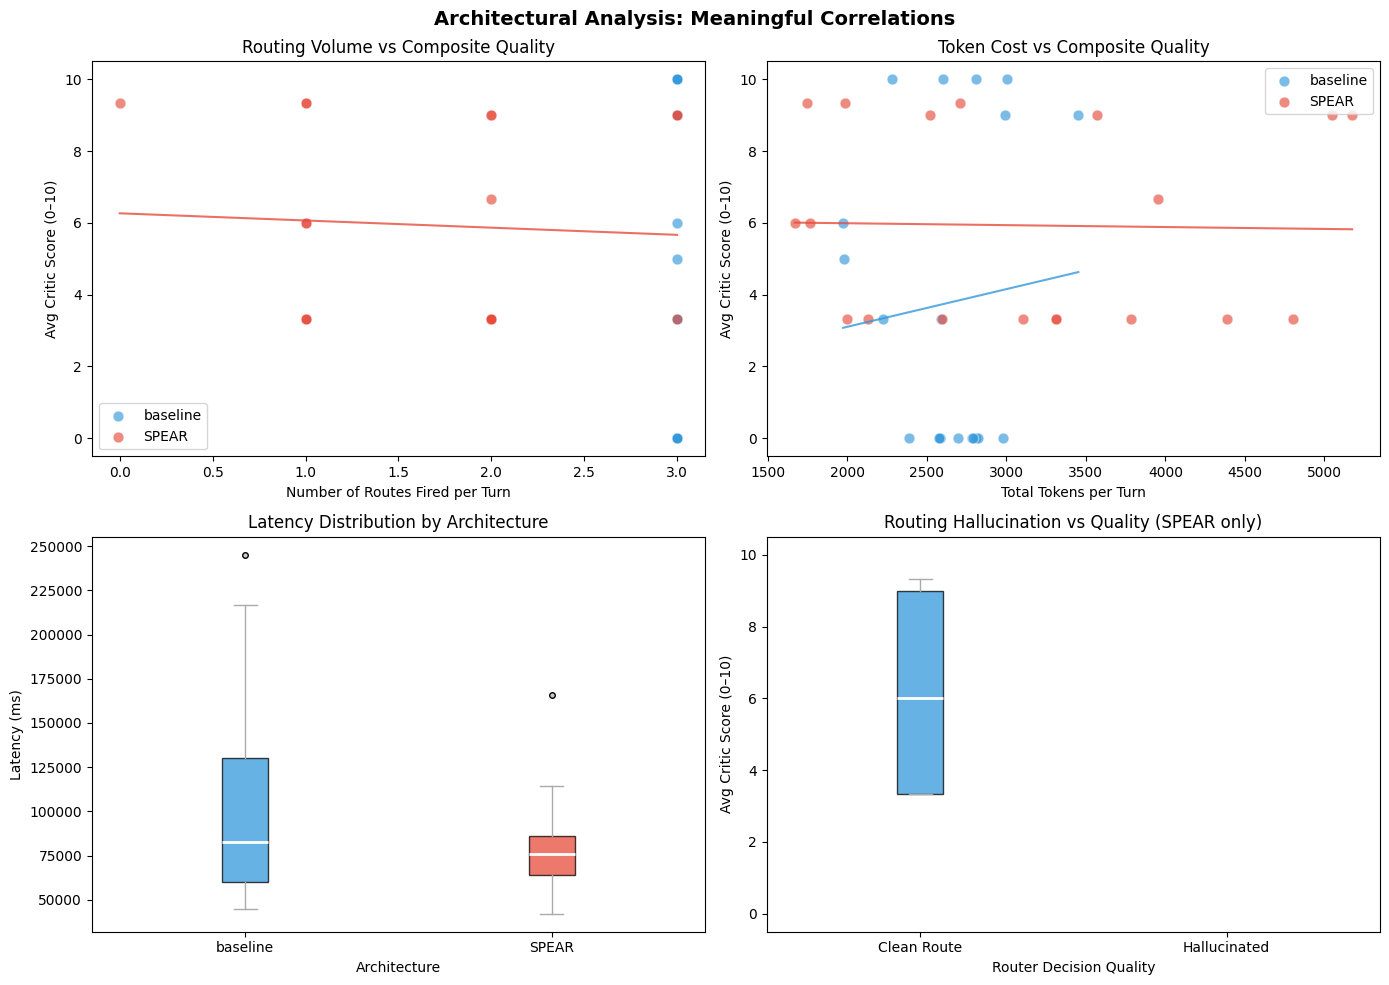

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Architectural Analysis: Meaningful Correlations', fontsize=14, fontweight='bold')

# Plot 1: Routing Volume vs Composite Quality
ax = axes[0, 0]
for arch, color in [('baseline', '#3498db'), ('SPEAR', '#e74c3c')]:
    subset = df[df['architecture'] == arch]
    ax.scatter(subset['num_routes'], subset['avg_critic_score'],
               color=color, alpha=0.65, s=60, label=arch, edgecolors='white', linewidths=0.5)
    if len(subset) > 2:
        m, b = np.polyfit(subset['num_routes'], subset['avg_critic_score'], 1)
        xs = np.linspace(subset['num_routes'].min(), subset['num_routes'].max(), 100)
        ax.plot(xs, m * xs + b, color=color, linewidth=1.5, alpha=0.8)
ax.set_title('Routing Volume vs Composite Quality')
ax.set_xlabel('Number of Routes Fired per Turn')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(-0.5, 10.5)
ax.legend()

# Plot 2: Token Cost vs Composite Quality
ax = axes[0, 1]
for arch, color in [('baseline', '#3498db'), ('SPEAR', '#e74c3c')]:
    subset = df[df['architecture'] == arch]
    ax.scatter(subset['total_tokens'], subset['avg_critic_score'],
               color=color, alpha=0.65, s=60, label=arch, edgecolors='white', linewidths=0.5)
    if len(subset) > 2:
        m, b = np.polyfit(subset['total_tokens'], subset['avg_critic_score'], 1)
        xs = np.linspace(subset['total_tokens'].min(), subset['total_tokens'].max(), 100)
        ax.plot(xs, m * xs + b, color=color, linewidth=1.5, alpha=0.8)
ax.set_title('Token Cost vs Composite Quality')
ax.set_xlabel('Total Tokens per Turn')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(-0.5, 10.5)
ax.legend()

# Plot 3: Latency Distribution by Architecture
ax = axes[1, 0]
archs = ['baseline', 'SPEAR']
colors = ['#3498db', '#e74c3c']
data_by_arch = [df[df['architecture'] == a]['latency_ms'].dropna().values for a in archs]
bp = ax.boxplot(data_by_arch, labels=archs, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#AAAAAA'),
                capprops=dict(color='#AAAAAA'),
                flierprops=dict(marker='o', markerfacecolor='#CCCCCC', markersize=4))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title('Latency Distribution by Architecture')
ax.set_xlabel('Architecture')
ax.set_ylabel('Latency (ms)')

# Plot 4: Routing Hallucination vs Composite Quality (SPEAR only)
ax = axes[1, 1]
spear_only = df[df['architecture'] == 'SPEAR'].copy()
spear_only['hallucination_label'] = spear_only['routing_hallucination'].map(
    {True: 'Hallucinated', False: 'Clean Route'}
)
hallu_order = ['Clean Route', 'Hallucinated']
hallu_colors = ['#3498db', '#e74c3c']
hallu_data = [
    spear_only[spear_only['hallucination_label'] == label]['avg_critic_score'].dropna().values
    for label in hallu_order
]
bp2 = ax.boxplot(hallu_data, labels=hallu_order, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#AAAAAA'),
                 capprops=dict(color='#AAAAAA'),
                 flierprops=dict(marker='o', markerfacecolor='#CCCCCC', markersize=4))
for patch, color in zip(bp2['boxes'], hallu_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title('Routing Hallucination vs Quality (SPEAR only)')
ax.set_xlabel('Router Decision Quality')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(-0.5, 10.5)

plt.tight_layout()
plt.show()

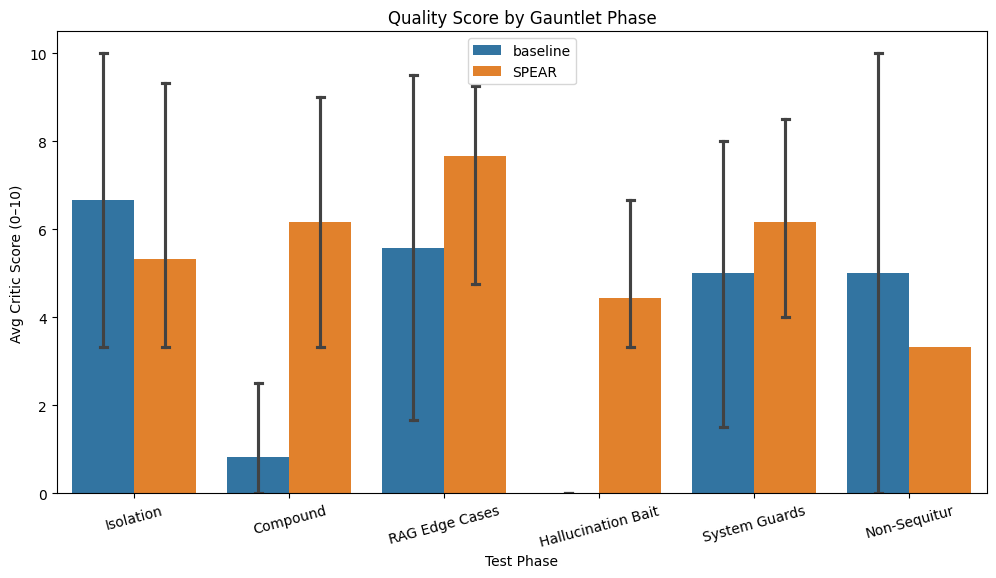

In [48]:
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur'
]

# Assign to both architectures by turn order
df['phase'] = df.groupby('architecture').cumcount().map(
    dict(enumerate(phase_labels))
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='phase',
    y='avg_critic_score',
    hue='architecture',
    data=df,
    capsize=0.1
)
plt.title('Quality Score by Gauntlet Phase')
plt.xlabel('Test Phase')
plt.ylabel('Avg Critic Score (0–10)')
plt.xticks(rotation=15)
plt.legend()
plt.show()

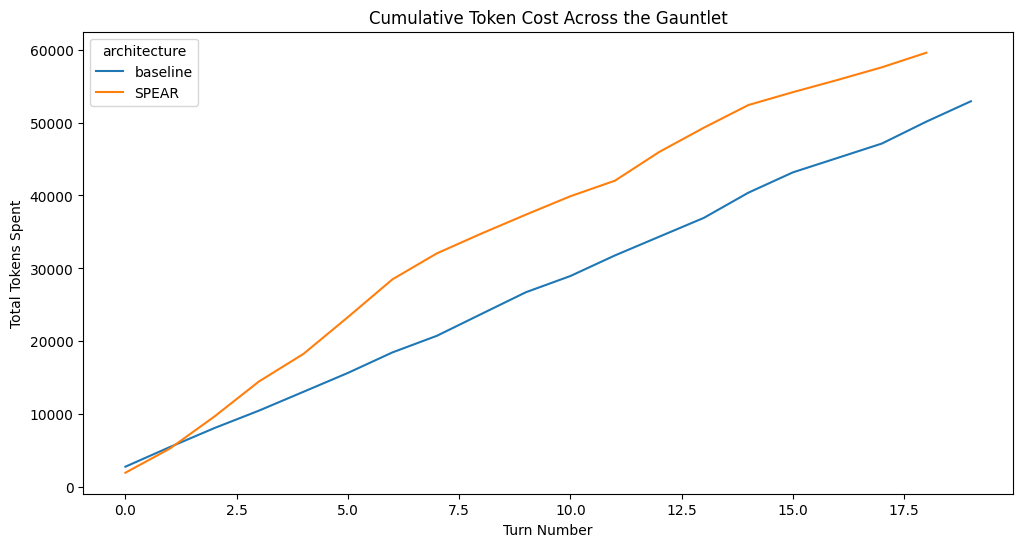

In [44]:
df_sorted = df.sort_values('timestamp_utc')
df_sorted['cumulative_tokens'] = df_sorted.groupby('architecture')['total_tokens'].cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=df_sorted.groupby('architecture').cumcount(), 
             y='cumulative_tokens', 
             hue='architecture', 
             data=df_sorted)
plt.title('Cumulative Token Cost Across the Gauntlet')
plt.xlabel('Turn Number')
plt.ylabel('Total Tokens Spent')
plt.show()

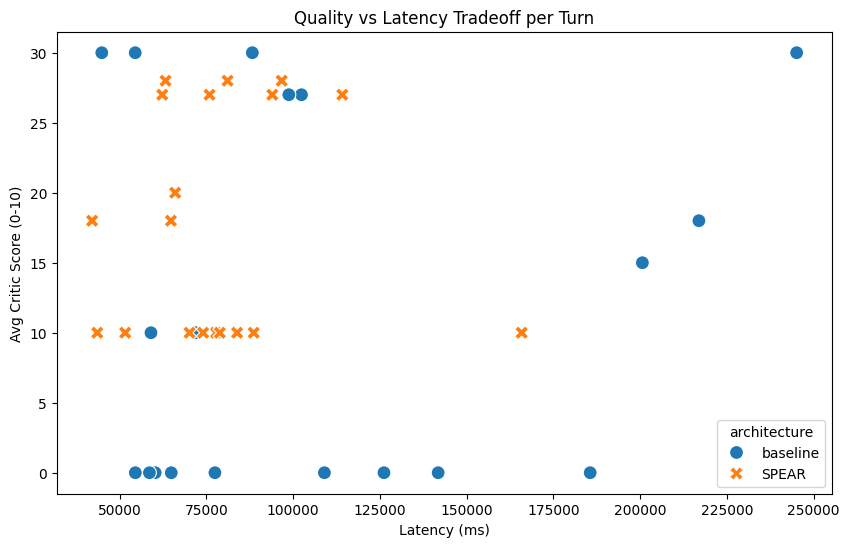

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='latency_ms', 
    y='total_critic_score',
    hue='architecture',
    style='architecture',
    s=100,
    data=df
)
plt.title('Quality vs Latency Tradeoff per Turn')
plt.xlabel('Latency (ms)')
plt.ylabel('Avg Critic Score (0-10)')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Latency Breakdown per Turn', fontsize=14, fontweight='bold')

# --- BASELINE ---
baseline_components = pd.DataFrame({
    'Safety':    baseline_df['latency_breakdown.safety_ms'].fillna(0),
    'Memory':    baseline_df['latency_breakdown.memory_ms'].fillna(0),
    'Arbiter':   baseline_df['latency_breakdown.arbiter_ms'].fillna(0),
    'DM':        baseline_df['latency_breakdown.dm_ms'].fillna(0),
    'NPC Agent': baseline_df['latency_breakdown.npc_agent_ms'].fillna(0),
    'Post':      baseline_df['latency_breakdown.post_processing_ms'].fillna(0),
})

baseline_colors = ['#AED6F1', '#5DADE2', '#1A5276', '#2E86C1', '#85C1E9', '#D6EAF8']
baseline_components.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=baseline_colors, edgecolor='white', linewidth=0.5
)
axes[0].set_title('Baseline — Latency Breakdown per Turn')
axes[0].set_xlabel('Turn Number')
axes[0].set_ylabel('Latency (ms)')
axes[0].set_xticks(range(len(baseline_components)))
axes[0].set_xticklabels([f"T{i+1}" for i in range(len(baseline_components))], rotation=45)
axes[0].legend(loc='upper right', fontsize=8)

# --- SPEAR ---
spear_components = pd.DataFrame({
    'Safety':       spear_df['latency_breakdown.safety_filter_ms'].fillna(0),
    'Router':       spear_df['latency_breakdown.router_ms'].fillna(0),
    'Parallel Fetch': spear_df['latency_breakdown.parallel_fetch_ms'].fillna(0),
    'DM':           spear_df['latency_breakdown.dm_ms'].fillna(0),
    'Post':         spear_df['latency_breakdown.post_processing_ms'].fillna(0),
})

spear_colors = ['#F9EBEA', '#F1948A', '#C0392B', '#922B21', '#FADBD8']
spear_components.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=spear_colors, edgecolor='white', linewidth=0.5
)
axes[1].set_title('SPEAR — Latency Breakdown per Turn')
axes[1].set_xlabel('Turn Number')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_xticks(range(len(spear_components)))
axes[1].set_xticklabels([f"T{i+1}" for i in range(len(spear_components))], rotation=45)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'latency_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

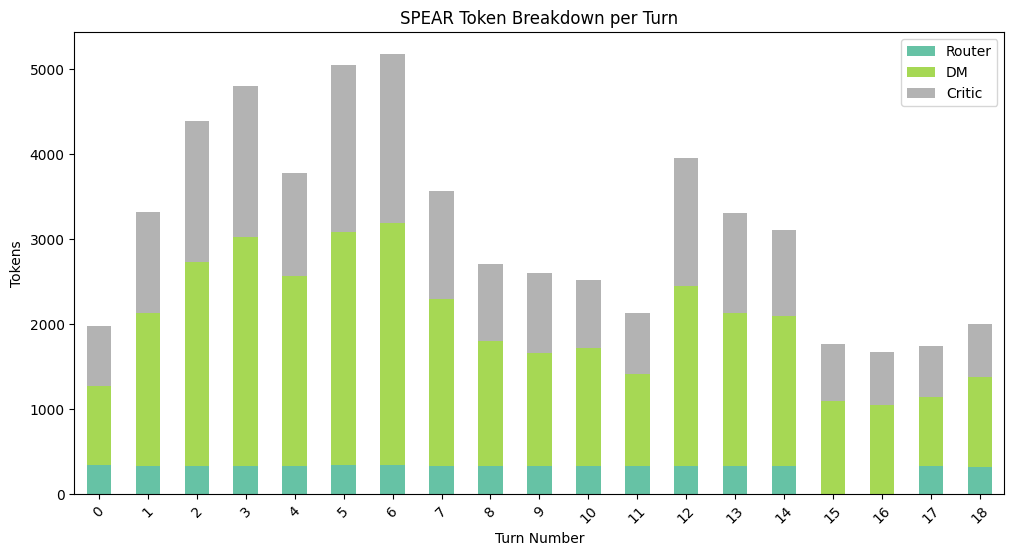

In [46]:
spear_df = df[df['architecture'] == 'SPEAR'].copy()

token_components = pd.DataFrame({
    'Router':  spear_df['token_breakdown.router'].values,
    'DM':      spear_df['token_breakdown.dm'].values,
    'Critic':  spear_df['token_breakdown.critic'].values,
})

token_components.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('SPEAR Token Breakdown per Turn')
plt.xlabel('Turn Number')
plt.ylabel('Tokens')
plt.xticks(rotation=45)
plt.show()

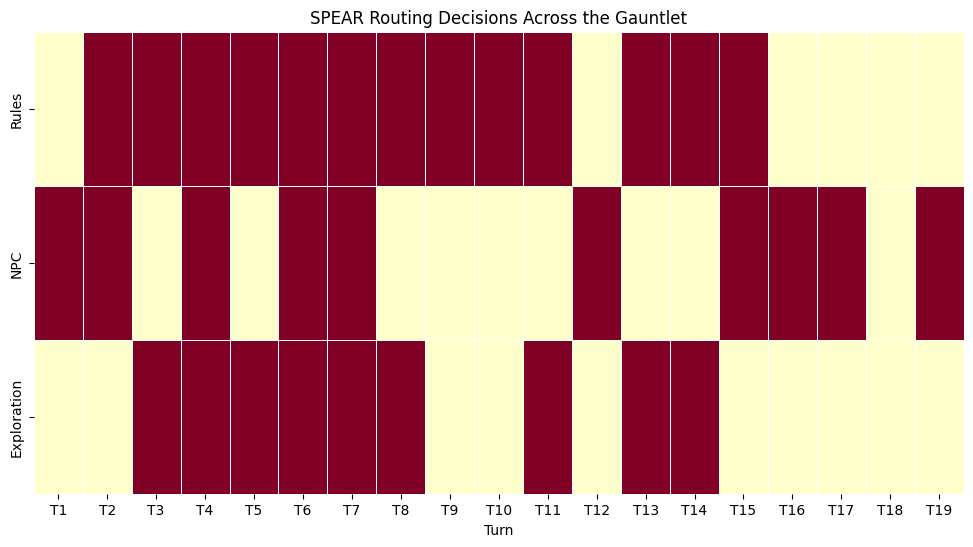

In [47]:
route_cols = ['routes_fired.rules_logic', 'routes_fired.npc_lore', 'routes_fired.world_exploration']
spear_routes = df[df['architecture'] == 'SPEAR'][route_cols].astype(int)
spear_routes.columns = ['Rules', 'NPC', 'Exploration']

plt.figure(figsize=(12, 6))
sns.heatmap(
    spear_routes.T, 
    cmap='YlOrRd', 
    cbar=False,
    linewidths=0.5,
    yticklabels=['Rules', 'NPC', 'Exploration'],
    xticklabels=[f"T{i+1}" for i in range(len(spear_routes))]
)
plt.title('SPEAR Routing Decisions Across the Gauntlet')
plt.xlabel('Turn')
plt.show()

/tmp/ipykernel_334828/3266779110.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='avg_critic_score', data=df,
/tmp/ipykernel_334828/3266779110.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='score_per_1k', data=df,
/tmp/ipykernel_334828/3266779110.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_arch, labels=['Baseline', 'SPEAR'], patch_artist=True,


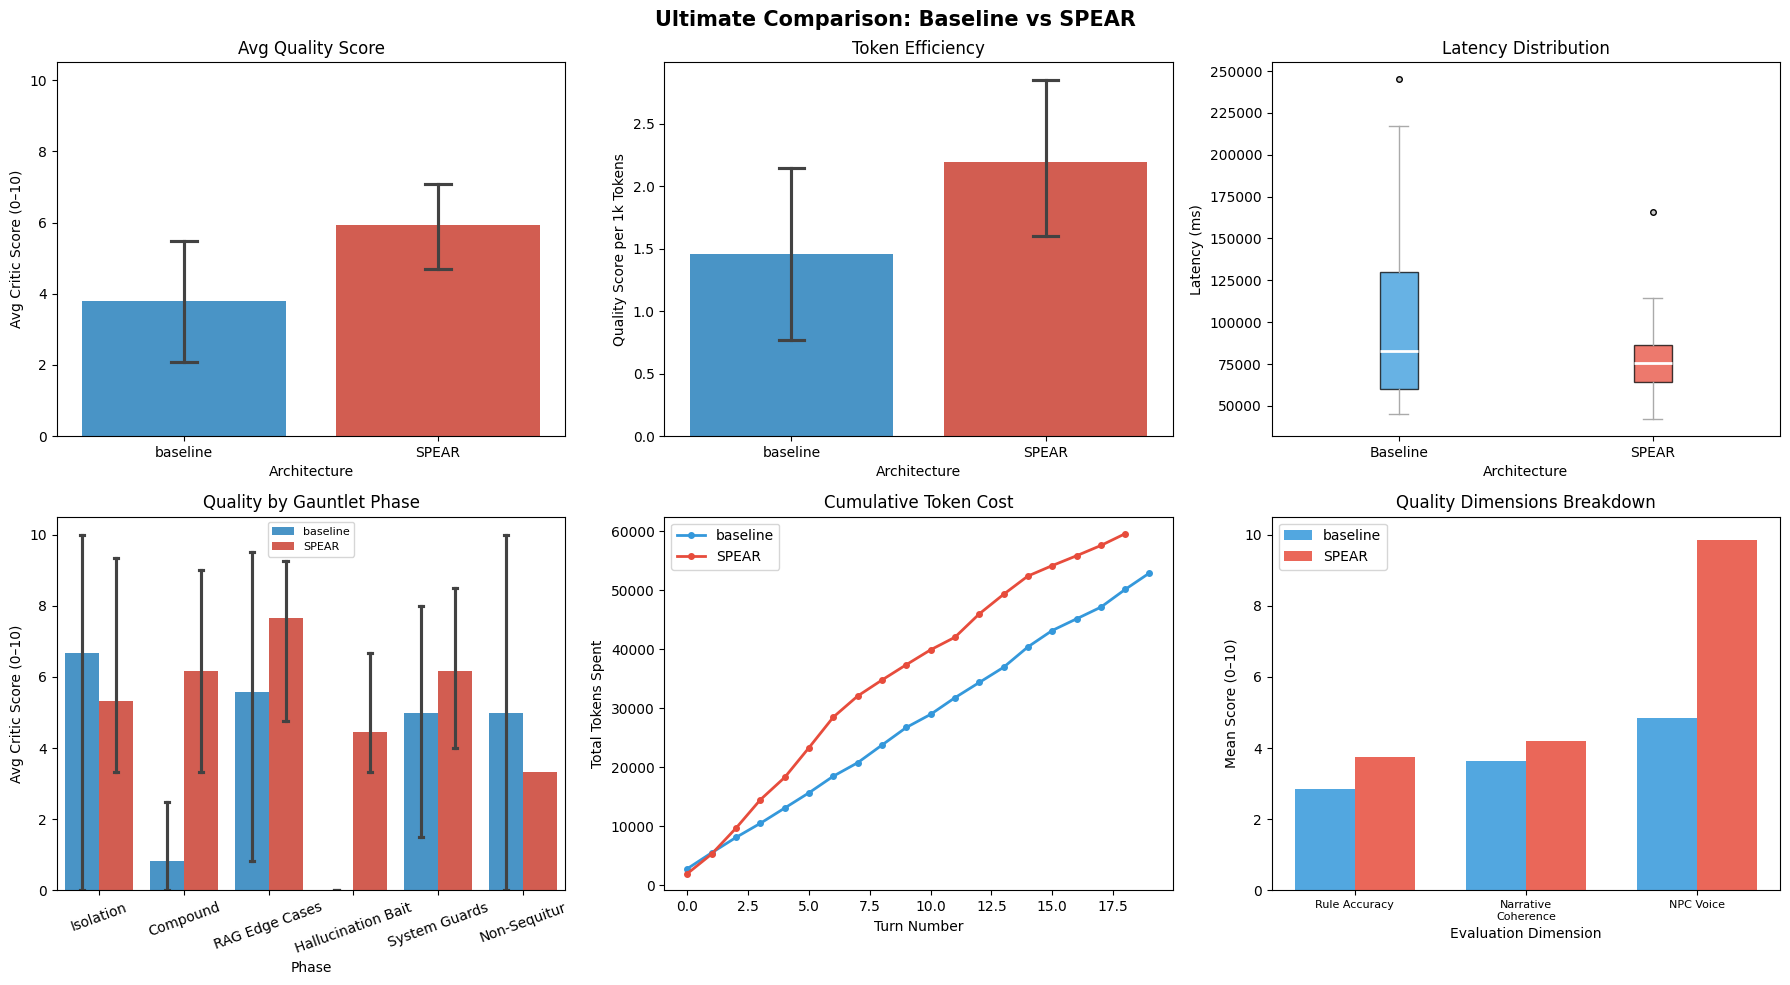

In [51]:
critic_cols = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]

df['avg_critic_score'] = df[critic_cols].mean(axis=1)
df['score_per_1k'] = (df['avg_critic_score'] / df['total_tokens']) * 1000

arch_colors = {'baseline': '#3498db', 'SPEAR': '#e74c3c'}
spear_label = df[df['architecture'] == 'SPEAR']['architecture'].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Ultimate Comparison: Baseline vs SPEAR", fontsize=15, fontweight='bold')

# 1. Avg Quality Score
ax = axes[0, 0]
sns.barplot(x='architecture', y='avg_critic_score', data=df,
            palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Avg Quality Score')
ax.set_xlabel('Architecture')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)

# 2. Token Efficiency
ax = axes[0, 1]
sns.barplot(x='architecture', y='score_per_1k', data=df,
            palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Token Efficiency')
ax.set_xlabel('Architecture')
ax.set_ylabel('Quality Score per 1k Tokens')

# 3. Latency Distribution
ax = axes[0, 2]
data_by_arch = [df[df['architecture'] == a]['latency_ms'].dropna().values for a in ['baseline', 'SPEAR']]
bp = ax.boxplot(data_by_arch, labels=['Baseline', 'SPEAR'], patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#AAAAAA'), capprops=dict(color='#AAAAAA'),
                flierprops=dict(marker='o', markerfacecolor='#CCCCCC', markersize=4))
for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title('Latency Distribution')
ax.set_xlabel('Architecture')
ax.set_ylabel('Latency (ms)')

# 4. Quality by Gauntlet Phase
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur'
]
df['phase'] = df.groupby('architecture').cumcount().map(dict(enumerate(phase_labels)))
ax = axes[1, 0]
sns.barplot(x='phase', y='avg_critic_score', hue='architecture',
            data=df, palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Quality by Gauntlet Phase')
ax.set_xlabel('Phase')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=8)

# 5. Cumulative Token Cost
ax = axes[1, 1]
df_sorted = df.sort_values('timestamp_utc')
df_sorted['cumulative_tokens'] = df_sorted.groupby('architecture')['total_tokens'].cumsum()
for arch, color in arch_colors.items():
    subset = df_sorted[df_sorted['architecture'] == arch].reset_index(drop=True)
    ax.plot(range(len(subset)), subset['cumulative_tokens'],
            color=color, linewidth=2, label=arch, marker='o', markersize=4)
ax.set_title('Cumulative Token Cost')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Total Tokens Spent')
ax.legend()

# 6. Quality Score Dimensions Side by Side
ax = axes[1, 2]
dims = ['async_critic_scores.rule_accuracy',
        'async_critic_scores.narrative_coherence',
        'async_critic_scores.npc_voice_consistency']
dim_labels = ['Rule Accuracy', 'Narrative\nCoherence', 'NPC Voice']
x = np.arange(len(dims))
width = 0.35
for i, (arch, color) in enumerate(arch_colors.items()):
    means = [df[df['architecture'] == arch][d].mean() for d in dims]
    ax.bar(x + i * width, means, width, label=arch, color=color, alpha=0.85)
ax.set_title('Quality Dimensions Breakdown')
ax.set_xlabel('Evaluation Dimension')
ax.set_ylabel('Mean Score (0–10)')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(dim_labels, fontsize=8)
ax.set_ylim(0, 10.5)
ax.legend()

plt.tight_layout()
plot_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'plot')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'mistral-small3.2_llama3.2.png'), dpi=150, bbox_inches='tight')
plt.show()